Домашнее задание. Логистическая регрессия и разные виды линейной регрессии (с регуляризацией)

Задача 1: Первичный анализ данных House Prices(1 балл)

Датасет: [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview)

Требуется:

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной SalePrice

- Выявите и обработайте пропущенные значения в данных

In [1]:
! gdown 1SKx5Shx5J1O45mKBmjCtQmUF7LXRUou-

Downloading...
From: https://drive.google.com/uc?id=1SKx5Shx5J1O45mKBmjCtQmUF7LXRUou-
To: /content/train.csv
100% 461k/461k [00:00<00:00, 40.2MB/s]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")

In [4]:
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
print(df.shape)

(1460, 81)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
display(df.describe())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Наблюдаем пропуски в некоторых колонках, их будем обрабатывать.

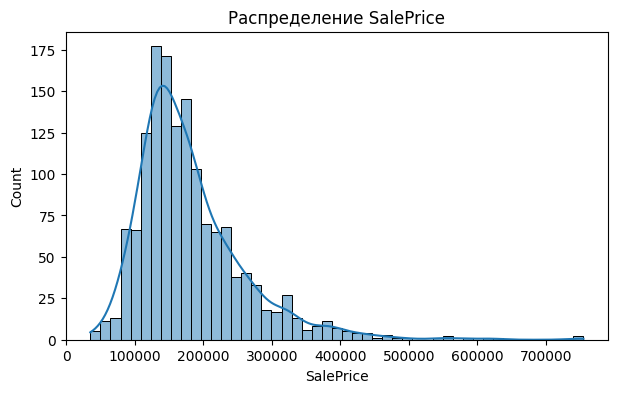

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Распределение SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

Гистограмма сильно смещена вправо (много дешёвых домов и длинный хвост дорогих). Есть выбросы - 500–750к. Такое распределение не очень похоже на нормальное, линейная регрессия может работать хуже.

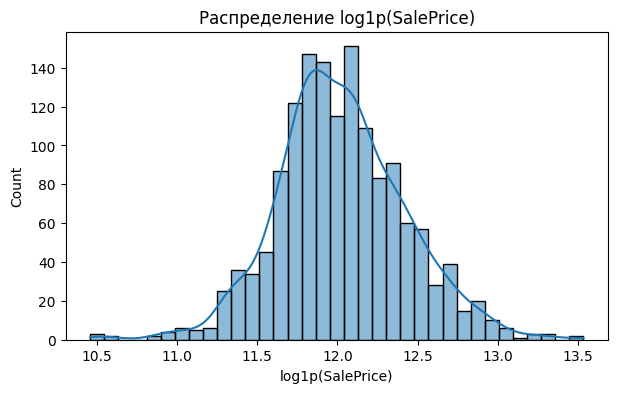

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(df["SalePrice"]), kde=True)
plt.title("Распределение log1p(SalePrice)")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

После логарифмирования распределение стало почти симметричным, колоколообразным.
Хвост укоротился, выбросы менее экстремальные.
Такой таргет лучше соответствует предположениям линейных моделей (ошибки ближе к нормальным, более стабильные оценки).

In [10]:
#Признаки с пропусками и количество этих пропусков
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [11]:
df_clean = df.copy()

# Пропуски в числовых признаках заменяем на медиану, которая устойчива к выбросам
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Пропуски в категориальных признаках заменяем самое частое значение
cat_cols = df_clean.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Проверим, что пропусков больше нет
df_clean.isna().sum().max()

0

Задача 2: Построение базовой модели (1 балл)

Требуется:

- Разделите данные на обучающую и тестовую выборки в соотношении 80/20

- Обучите модель LinearRegression на обучающей выборке, используя только числовые признаки

- Выберите метрику для сравнения моделей и обоснуйте свой выбор
- Рассчитайте свою метрику на тестовой выборке

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns

y = df_clean["SalePrice"]

# Id нет смысла учитывать
X = df_clean[num_cols].drop(columns=["SalePrice", "Id"])

print(X.shape, y.shape)

(1460, 36) (1460,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = np.mean(np.abs(y_test - y_pred)) #для сравнения
r2 = r2_score(y_test, y_pred) #для сравнения

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R^2:  {r2:.4f}")

RMSE: 36836.91
MAE:  22975.86
R^2:  0.8231


Обоснование выбора метрики:

В качестве основной метрики выбран RMSE, потому что она измеряется в тех же единицах, что и SalePrice(доллары), т.е. можно интерпретировать как средняя ошибка прогноза в долларах, а также сильнее штрафует крупные ошибки, чем MAE.

Задача 3: Предобработка данных и интерпретация модели (2 балл)

Требуется:

- Закодируйте категориальные переменные методами One-Hot Encoding или Label Encoding

- Масштабируйте числовые признаки с помощью StandardScaler

- Обучите LinearRegression на обучающих данных и оцените качество на тестовых данных по выбранной метрике

- Выведите 5 самых важных признаков по абсолютному значению коэффициентов

- Проанализируйте, какие факторы больше всего влияют на модель

Подсказка:
Зачем вообще нужен StandardScaler и One-Hot Encoding или Label Encoding ?

1) StandardScaler - для чего нужен:
- Нормализует масштаб числовых признаков (приводит к среднему=0, std=1)
- Зачем: Многие алгоритмы ML чувствительны к масштабу данных.
Пример проблемы: Признак "Площадь дома" (100-300 м²) и "Количество комнат" (1-5)без масштабирования алгоритм придаст больше веса площади, но после масштабирования - оба признака будут в одинаковом масштабе.

2) One-Hot Encoding/Label Encoding - для чего нужны:

- Label Encoding : Преобразует категории в числа. Сохраняет размерность данных, но может создать ложную порядковость (0 < 1 < 2)!

- One-Hot Encoding: Создает бинарные столбцы для каждой категории.Убирает ложную порядковость, но увеличивает размерность данных (проклятие размерности)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
X = df_clean.drop(columns=["SalePrice", "Id"])
y = df_clean["SalePrice"]

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Числовых признаков:", len(num_cols))
print("Категориальных признаков:", len(cat_cols))

Числовых признаков: 36
Категориальных признаков: 43


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_num = pd.DataFrame(X_train_num, columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num, columns=num_cols, index=X_test.index)


In [21]:
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)

X_train_proc = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_proc = pd.concat([X_test_num, X_test_cat], axis=1)
X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)

print(X_train_proc.shape, X_test_proc.shape)

(1168, 242) (292, 242)


In [22]:
lin_reg_full = LinearRegression()
lin_reg_full.fit(X_train_proc, y_train)

y_pred_full = lin_reg_full.predict(X_test_proc)

mse = mean_squared_error(y_test, y_pred_full)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_full)

print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

RMSE: 605367.78
R^2:  -46.7776


In [23]:
coefs = pd.Series(lin_reg_full.coef_, index=X_train_proc.columns)
top5 = coefs.reindex(coefs.abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по абсолютному значению коэффициента:")
display(top5)


Топ-5 признаков по абсолютному значению коэффициента:


,0
RoofMatl_Metal,703481.026720
RoofMatl_WdShngl,668839.346946
RoofMatl_Tar&Grv,660271.426169
RoofMatl_CompShg,656521.518961
RoofMatl_WdShake,655688.000282


Выводы:

По сравнению с базовой моделью качество резко ухудшилось. Много (242) признаков, из них десятки one-hot столбцов для редких категорий. Обычная LinearRegression без регуляризации даёт огромные коэффициенты на редких категориях (RoofMatl_...), модель становится очень нестабильной. Отсюда и странный топ-5 признаков: вряд ли тип крыши является ключевым фактором:)

Задача 4: Регуляризация и подбор гиперпараметров (1 балл)

Требуется:

- Создайте Pipeline с MinMaxScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Создайте Pipeline с StandardScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Для оценки качества используйте выбранную ранее метрику

In [25]:
y = df_clean["SalePrice"]

X = df_clean.drop(columns=["SalePrice", "Id"])

X = pd.get_dummies(X, drop_first=True)

print("Форма X после OHE:", X.shape)

Форма X после OHE: (1460, 244)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

In [32]:
pipe_minmax = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

grid_minmax = GridSearchCV(
    pipe_minmax,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_minmax.fit(X_train, y_train)

print("Лучшие параметры (MinMax):", grid_minmax.best_params_)

best_mse_cv = -grid_minmax.best_score_
best_rmse_cv = np.sqrt(best_mse_cv)
print(f"CV RMSE (MinMax): {best_rmse_cv:.2f}")

y_pred_minmax = grid_minmax.best_estimator_.predict(X_test)
mse_test_minmax = mean_squared_error(y_test, y_pred_minmax)
rmse_test_minmax = np.sqrt(mse_test_minmax)
print(f"Test RMSE (MinMax): {rmse_test_minmax:.2f}")

Лучшие параметры (MinMax): {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
CV RMSE (MinMax): 32471.85
Test RMSE (MinMax): 32977.03


In [33]:
best_en_minmax = grid_minmax.best_estimator_.named_steps["model"]
coefs_minmax = pd.Series(best_en_minmax.coef_, index=X_train.columns)

zero_minmax = coefs_minmax[coefs_minmax == 0]
nonzero_minmax = coefs_minmax[coefs_minmax != 0]

print("MinMax: занулено признаков:", len(zero_minmax), "из", len(coefs_minmax))
display(zero_minmax.head())

MinMax: занулено признаков: 2 из 244


,0
RoofMatl_Membran,0.0
Electrical_Mix,0.0


In [37]:
threshold = 1e-3
small_minmax = coefs_minmax[coefs_minmax.abs() < threshold]
print("MinMax: почти нулевых признаков:", len(small_minmax), "из", len(coefs_minmax))
display(small_minmax.sort_values().head(10))

MinMax: почти нулевых признаков: 2 из 244


,0
RoofMatl_Membran,0.0
Electrical_Mix,0.0


In [34]:
pipe_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

grid_std = GridSearchCV(
    pipe_std,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_std.fit(X_train, y_train)

print("Лучшие параметры (StandardScaler):", grid_std.best_params_)

best_mse_cv_std = -grid_std.best_score_
best_rmse_cv_std = np.sqrt(best_mse_cv_std)
print(f"CV RMSE (Standard): {best_rmse_cv_std:.2f}")

y_pred_std = grid_std.best_estimator_.predict(X_test)
mse_test_std = mean_squared_error(y_test, y_pred_std)
rmse_test_std = np.sqrt(mse_test_std)
print(f"Test RMSE (Standard): {rmse_test_std:.2f}")

Лучшие параметры (StandardScaler): {'model__alpha': 1, 'model__l1_ratio': 0.5}
CV RMSE (Standard): 34532.67
Test RMSE (Standard): 33260.62


In [35]:
best_en_std = grid_std.best_estimator_.named_steps["model"]
coefs_std = pd.Series(best_en_std.coef_, index=X_train.columns)

zero_std = coefs_std[coefs_std == 0]
nonzero_std = coefs_std[coefs_std != 0]

print("Standard: занулено признаков:", len(zero_std), "из", len(coefs_std))
display(zero_std.head())

Standard: занулено признаков: 2 из 244


,0
RoofMatl_Membran,0.0
Electrical_Mix,0.0


In [38]:
threshold = 1e-3

small_std = coefs_std[coefs_std.abs() < threshold]
print("Standard: почти нулевых признаков:", len(small_std), "из", len(coefs_std))
display(small_std.sort_values().head(10))

Standard: почти нулевых признаков: 2 из 244


,0
RoofMatl_Membran,0.0
Electrical_Mix,0.0


Вопросы для анализа:(1 балл)

1. Сравните оптимальные параметры в двух экспериментах

2. Сравните качество модели на тестовой выборке в обоих случаях

3. Проанализируйте, какие признаки были занулены в каждом эксперименте и объясните возможные причины

4. Сделайте вывод о влиянии типа масштабирования на качество линейной регрессии

Ответ на вопрос:

1. MinMaxScaler + ElasticNet: alpha = 0.01, l1_ratio = 0.1 - очень слабая регуляризация, и в основном L2 (Ridge-часть), т.к. L1-доля всего 10%.
StandardScaler + ElasticNet: alpha = 1, l1_ratio = 0.5 - регуляризация намного сильнее, смесь L1 и L2 примерно 50/50, то есть модель более грубо отсекает/сжимает коэффициенты. Разные скейлеры приводят к разным диапазонам значений признаков, соответственно один и тот же номинальный alpha фактически даёт разную силу штрафа, поэтому сетка выбрала разные оптимальные комбинации.

2. MinMaxScaler + ElasticNet: Test RMSE ≈ 32977; StandardScaler + ElasticNet: Test RMSE ≈ 33261. Оба варианта дают похожее качество на тесте - заметно лучше, чем переобученная OLS-модель из задачи 3 и немного лучше базовой модели только по числовым фичам. Небольшое преимущество по RMSE у MinMaxScaler + ElasticNet.

3. В обоих экспериментах ElasticNet занулил только 2 признака.
Это связано с тем, что оптимальные гиперпараметры подбирались по RMSE, а не по степени разреженности.
Получившиеся значения alpha и l1_ratio обеспечивают умеренную регуляризацию: большинство коэффициентов лишь сильно уменьшаются по модулю, но не становятся строго равны нулю.
Полное зануление произошло только для самых редких и бесполезных категорий (RoofMatl_Membran, Electrical_Mix).
Если увеличить alpha и l1_ratio, можно добиться большего числа нулей, но это ухудшит качество модели.

4. Масштабирование необходимо: без приведения признаков к сопоставимому масштабу ElasticNet работал бы некорректно, т.к. штраф завязан на абсолютные значения коэффициентов, а те зависят от масштаба признаков. При MinMax значения в [0, 1], сетка выбирает маленький alpha. При StandardScaler (среднее 0, std 1), для такого же эффекта нужна другая величина alpha,  модель выбрала alpha=1 и более сильный L1-компонент. По качеству на тесте существенной разницы нет, т.е. в этом датасете выбор скейлера практически не меняет финальную ошибку.

Задача 5: Бинарная классификация с помощью логистической регрессии (2 балла)

Требуется:

- Создайте бинарную целевую переменную expensive (1 - если цена выше медианы, 0 - в противном случае)

- Обучите модель LogisticRegression с L2-регуляризацией

- Выполните подбор гиперпараметров с помощью GridSearchCV

- Оцените качество модели с помощью метрики F1-score

- Для лучшей модели выведите Топ-5 самых важных признаков

Примечание: Не забудьте разделить данные на обучающую и тестовую выборки перед обучением модели с тем же random_state.

In [39]:
median_price = df_clean["SalePrice"].median()
median_price

163000.0

In [41]:
df_clean["expensive"] = (df_clean["SalePrice"] > median_price).astype(int)

df_clean["expensive"].value_counts()

,count
expensive,
0,732
1,728


In [42]:
X = df_clean.drop(columns=["SalePrice", "Id", "expensive"])
y = df_clean["expensive"]

X = pd.get_dummies(X, drop_first=True)
X.shape

(1460, 244)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

In [45]:
pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=10000,
        solver="liblinear",
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_logreg.fit(X_train, y_train)

print("Лучшие параметры:", grid_logreg.best_params_)
print("Лучший CV F1:", grid_logreg.best_score_)

Лучшие параметры: {'model__C': 0.01}
Лучший CV F1: 0.9165914600555174


In [46]:
best_model = grid_logreg.best_estimator_

y_pred = best_model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"Test F1-score: {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Test F1-score: 0.9072

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       146
           1       0.91      0.90      0.91       146

    accuracy                           0.91       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.91      0.91      0.91       292



In [47]:
logreg = best_model.named_steps["model"]

coefs = pd.Series(logreg.coef_[0], index=X_train.columns)

top5 = coefs.reindex(coefs.abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по |коэффициенту|:")
display(top5)

Топ-5 признаков по |коэффициенту|:


,0
FullBath,0.285143
GrLivArea,0.256462
OverallQual,0.232807
GarageCars,0.208236
Fireplaces,0.199045


Проанализируй все модели и ответе на вопросы :(2 балла)

1) Какая модель показала наилучшие результаты для регрессии и почему?

2) Как регуляризация повлияла на веса признаков?

3) Какие признаки оказались наиболее важными для предсказания цены дома?

4) Насколько хорошо логистическая регрессия справилась с бинарной классификацией?

5) Какие проблемы в данных могли повлиять на качество моделей?

Ответ на вопросы:

1. Лучшей по качеству(задачи регрессии 1-4) стала модель ElasticNet с MinMaxScaler, т.к. она использует регуляризацию (L1+L2), которая контролиреует коэффициенты и не даёт переобучаться на сотнях OHE-признаков, при этом учитывает и числовые, и категориальные признаки, поэтому описывает цену лучше, чем базовая линейка только на числовых фичах.

2. Регуляризация сгладила веса, убрала экстремальные значения и частично провела автоматический отбор признаков.

3. Топ-5 признаков по абсолютному значению коэффициента: FullBath – количество полноценных ванных комнат; GrLivArea – жилая площадь над землёй; OverallQual – общая оценка качества дома; GarageCars – вместимость гаража (в машинах); Fireplaces – количество каминов.
Интерпретация:
чем больше жилая площадь, ванных комнат, гаражных мест, каминов и чем выше общая оценка качества, тем выше вероятность, что дом будет дорогим, и тем выше предсказываемая цена в регрессионных моделях.

4. Test F1 ≈ 0.907, precision и recall для обоих классов ~0.90–0.91, accuracy ≈ 0.91. То есть логистическая регрессия даёт очень высокое качество, одинаково хорошо предсказывает оба класса, что логично, т.к. мы делили по медиане и классы примерно сбалансированы.

5. Большое число признаков и редких категорий: без регуляризации это привело к сильному переобучению линейной регрессии.

Мультиколлинеарность: много признаков сильно коррелируют, в обычной линейной регрессии это делает оценки коэффициентов неустойчивыми.

Выбросы и асимметричное распределение цены: SalePrice сильно скошена вправо, есть очень дорогие дома; без логарифмирования таргета и без робастных методов это ухудшает устойчивость регрессионных моделей.

Возможная нелинейность связей: мы используем только линейные модели; реальные зависимости цены от признаков могут быть частично нелинейными, что ограничивает максимум достижимого качества.

Правильнее было бы всё-таки логарифмировать таргет: cнижение влияния выбросов, более равномерная дисперсия ошибок, ближе к предположениям линейной регрессии.

Переделанное под логарифмированный таргет задание 2:

In [51]:
y_log = np.log1p(df_clean["SalePrice"])

In [52]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns

y = df_clean["SalePrice"]

# Id нет смысла учитывать
X = df_clean[num_cols].drop(columns=["SalePrice", "Id"])

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = np.mean(np.abs(y_test - y_pred)) #для сравнения
r2 = r2_score(y_test, y_pred) #для сравнения

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R^2:  {r2:.4f}")


(1460, 37) (1460,)
RMSE: 0.15
MAE:  0.11
R^2:  0.8789


Переделанное под логарифмированный таргет задание 3:

In [53]:
y_log = np.log1p(df_clean["SalePrice"])

In [54]:
X = df_clean.drop(columns=["SalePrice", "Id"])
y = df_clean["SalePrice"]

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Числовых признаков:", len(num_cols))
print("Категориальных признаков:", len(cat_cols))

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_num = pd.DataFrame(X_train_num, columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num, columns=num_cols, index=X_test.index)


X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)

X_train_proc = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_proc = pd.concat([X_test_num, X_test_cat], axis=1)
X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)

print(X_train_proc.shape, X_test_proc.shape)

lin_reg_full = LinearRegression()
lin_reg_full.fit(X_train_proc, y_train)

y_pred_full = lin_reg_full.predict(X_test_proc)

mse = mean_squared_error(y_test, y_pred_full)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_full)

print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

coefs = pd.Series(lin_reg_full.coef_, index=X_train_proc.columns)
top5 = coefs.reindex(coefs.abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по абсолютному значению коэффициента:")
display(top5)




Числовых признаков: 37
Категориальных признаков: 43
(1168, 243) (292, 243)
RMSE: 2.57
R^2:  -34.4761
Топ-5 признаков по абсолютному значению коэффициента:


,0
RoofMatl_Roll,2.598967
RoofMatl_Metal,2.586611
RoofMatl_WdShake,2.544916
RoofMatl_WdShngl,2.520643
RoofMatl_CompShg,2.518588


Переделанное под логарифмированный таргет задание 4:

In [55]:
y_log = np.log1p(df_clean["SalePrice"])

In [56]:
y = df_clean["SalePrice"]

X = df_clean.drop(columns=["SalePrice", "Id"])

X = pd.get_dummies(X, drop_first=True)

print("Форма X после OHE:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

pipe_minmax = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

grid_minmax = GridSearchCV(
    pipe_minmax,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_minmax.fit(X_train, y_train)

print("Лучшие параметры (MinMax):", grid_minmax.best_params_)

best_mse_cv = -grid_minmax.best_score_
best_rmse_cv = np.sqrt(best_mse_cv)
print(f"CV RMSE (MinMax): {best_rmse_cv:.2f}")

y_pred_minmax = grid_minmax.best_estimator_.predict(X_test)
mse_test_minmax = mean_squared_error(y_test, y_pred_minmax)
rmse_test_minmax = np.sqrt(mse_test_minmax)
print(f"Test RMSE (MinMax): {rmse_test_minmax:.2f}")

best_en_minmax = grid_minmax.best_estimator_.named_steps["model"]
coefs_minmax = pd.Series(best_en_minmax.coef_, index=X_train.columns)

zero_minmax = coefs_minmax[coefs_minmax == 0]
nonzero_minmax = coefs_minmax[coefs_minmax != 0]

print("MinMax: занулено признаков:", len(zero_minmax), "из", len(coefs_minmax))
display(zero_minmax.head())

threshold = 1e-3
small_minmax = coefs_minmax[coefs_minmax.abs() < threshold]
print("MinMax: почти нулевых признаков:", len(small_minmax), "из", len(coefs_minmax))
display(small_minmax.sort_values().head(10))

pipe_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

grid_std = GridSearchCV(
    pipe_std,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_std.fit(X_train, y_train)

print("Лучшие параметры (StandardScaler):", grid_std.best_params_)

best_mse_cv_std = -grid_std.best_score_
best_rmse_cv_std = np.sqrt(best_mse_cv_std)
print(f"CV RMSE (Standard): {best_rmse_cv_std:.2f}")

y_pred_std = grid_std.best_estimator_.predict(X_test)
mse_test_std = mean_squared_error(y_test, y_pred_std)
rmse_test_std = np.sqrt(mse_test_std)
print(f"Test RMSE (Standard): {rmse_test_std:.2f}")

best_en_std = grid_std.best_estimator_.named_steps["model"]
coefs_std = pd.Series(best_en_std.coef_, index=X_train.columns)

zero_std = coefs_std[coefs_std == 0]
nonzero_std = coefs_std[coefs_std != 0]

print("Standard: занулено признаков:", len(zero_std), "из", len(coefs_std))
display(zero_std.head())

threshold = 1e-3

small_std = coefs_std[coefs_std.abs() < threshold]
print("Standard: почти нулевых признаков:", len(small_std), "из", len(coefs_std))
display(small_std.sort_values().head(10))


Форма X после OHE: (1460, 245)
Лучшие параметры (MinMax): {'model__alpha': 0.001, 'model__l1_ratio': 0.5}
CV RMSE (MinMax): 0.14
Test RMSE (MinMax): 0.14
MinMax: занулено признаков: 143 из 245


,0
LotFrontage,-0.0
LotArea,0.0
MasVnrArea,0.0
BsmtFinSF1,0.0
BsmtFinSF2,0.0


MinMax: почти нулевых признаков: 145 из 245


,0
GarageYrBlt,-0.000396
LotFrontage,-0.000000
MasVnrArea,0.000000
LotArea,0.000000
BsmtFinSF2,0.000000
TotalBsmtSF,0.000000
LowQualFinSF,0.000000
BsmtFinSF1,0.000000
BsmtHalfBath,0.000000
KitchenAbvGr,-0.000000


Лучшие параметры (StandardScaler): {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
CV RMSE (Standard): 0.15
Test RMSE (Standard): 0.15
Standard: занулено признаков: 185 из 245


,0
LotFrontage,0.0
MasVnrArea,0.0
BsmtFinSF2,0.0
BsmtUnfSF,0.0
2ndFlrSF,0.0


Standard: почти нулевых признаков: 193 из 245


,0
ExterQual_Fa,-0.000590
KitchenAbvGr,-0.000528
ExterCond_Fa,-0.000488
HeatingQC_Gd,-0.000151
GarageType_CarPort,-0.000059
LowQualFinSF,-0.000000
2ndFlrSF,0.000000
LotFrontage,0.000000
EnclosedPorch,-0.000000
BedroomAbvGr,0.000000


Переделанное под логарифмированный таргет задание 5:

In [57]:
y_log = np.log1p(df_clean["SalePrice"])

In [59]:
median_price = np.log1p(df_clean["SalePrice"]).median()
median_price

df_clean["expensive"] = (np.log1p(df_clean["SalePrice"]) > median_price).astype(int)

df_clean["expensive"].value_counts()

X = df_clean.drop(columns=["SalePrice", "Id", "expensive"])
y = df_clean["expensive"]

X = pd.get_dummies(X, drop_first=True)
X.shape

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=10000,
        solver="liblinear",
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_logreg.fit(X_train, y_train)

print("Лучшие параметры:", grid_logreg.best_params_)
print("Лучший CV F1:", grid_logreg.best_score_)

best_model = grid_logreg.best_estimator_

y_pred = best_model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"Test F1-score: {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

logreg = best_model.named_steps["model"]

coefs = pd.Series(logreg.coef_[0], index=X_train.columns)

top5 = coefs.reindex(coefs.abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по |коэффициенту|:")
display(top5)



Лучшие параметры: {'model__C': 0.01}
Лучший CV F1: 0.9165914600555174
Test F1-score: 0.9072

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       146
           1       0.91      0.90      0.91       146

    accuracy                           0.91       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.91      0.91      0.91       292

Топ-5 признаков по |коэффициенту|:


,0
FullBath,0.285143
GrLivArea,0.256462
OverallQual,0.232807
GarageCars,0.208236
Fireplaces,0.199045


Результаты:

Линейные регрессионные модели стали лучше и стабильнее по R², особенно заметно в базовой модели.

Без регуляризации всё равно плохо, но лог-таргет хотя бы уменьшил масштаб метрик и коэффициентов.

ElasticNet на лог-таргете:
даёт немного лучшее качество, чем базовая лог-линейка, становится очень разреженным, модель проще, интерпретируемее и менее склонна к переобучению.

Логистическая регрессия почти не изменилась — она решает другую задачу и использует бинарный таргет, завязанный на медиану цены.